# Local SLM Benchmark — Model Comparison Analysis

Reads all CSVs from `benchmark/results/` and produces comparison tables and charts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.2f}".format)

RESULTS_DIR = Path("../benchmark/results")
MODELS = ["llama3.2", "phi4-mini", "qwen2.5:3b"]
TASKS  = ["log_classify", "code_review", "doc_extract"]
COLORS = {"llama3.2": "#4C72B0", "phi4-mini": "#DD8452", "qwen2.5:3b": "#55A868"}


Matplotlib is building the font cache; this may take a moment.


## 1. Load Results

In [2]:
csv_files = list(RESULTS_DIR.glob("*.csv"))
print(f"Found {len(csv_files)} result files:")
for f in sorted(csv_files):
    print(f"  {f.name}")

df = None  # guard: subsequent cells check 'df is not None' before using it

if not csv_files:
    print("\nNo results yet. Run the benchmark harness first:")
    print("  python -m benchmark.harness --task all --model all")
else:
    df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
    # .replace() handles both cases: already-bool columns (no-op) and string columns ("True"/"False" -> True/False)
    # Do NOT use .astype(bool) — it converts the string "False" to True since bool("False") is True in Python
    df["success"]    = df["success"].replace({"True": True, "False": False})
    df["cold_start"] = df["cold_start"].replace({"True": True, "False": False})
    print(f"\nTotal rows: {len(df)}")
    print(f"Models:     {sorted(df.model.unique())}")
    print(f"Tasks:      {sorted(df.task.unique())}")
    df.head(3)


Found 9 result files:
  code_review__llama3.2__20260319_211121.csv
  code_review__phi4-mini__20260319_215610.csv
  code_review__qwen2.5-3b__20260319_225629.csv
  doc_extract__llama3.2__20260320_080413.csv
  doc_extract__phi4-mini__20260320_090212.csv
  doc_extract__qwen2.5-3b__20260320_104252.csv
  log_classify__llama3.2__20260319_083858.csv
  log_classify__phi4-mini__20260319_101433.csv
  log_classify__qwen2.5-3b__20260319_202951.csv

Total rows: 2250
Models:     ['llama3.2', 'phi4-mini', 'qwen2.5:3b']
Tasks:      ['code_review', 'doc_extract', 'log_classify']


## 2. Overall Summary Table

Validity rate, mean tok/s, and mean total_ms per model x task.

In [3]:
if df is None:
    print("No data loaded. Run cell 1 first.")
else:
    summary = (
        df.groupby(["model", "task"])
        .agg(
            total_runs    =("run_id",        "count"),
            validity_rate =("success",       lambda x: round(x.mean() * 100, 1)),
            avg_toks      =("tokens_per_sec","mean"),
            avg_total_ms  =("total_ms",      "mean"),
            avg_retry     =("retry_count",   "mean"),
        )
        .round(2)
        .reset_index()
    )

    for metric, label in [
        ("validity_rate", "Validity Rate (%)"),
        ("avg_toks",      "Avg tokens/sec"),
        ("avg_total_ms",  "Avg total_ms"),
    ]:
        print(f"=== {label} ===")
        print(
            summary.pivot_table(index="model", columns="task", values=metric)
            .round(2)
            .to_string()
        )
        print()


=== Validity Rate (%) ===


task        code_review  doc_extract  log_classify
model                                             
llama3.2         100.00       100.00         94.00
phi4-mini         88.00       100.00         76.00
qwen2.5:3b       100.00       100.00         96.00

=== Avg tokens/sec ===
task        code_review  doc_extract  log_classify
model                                             
llama3.2           8.84         8.27          5.12
phi4-mini          6.85         4.90          6.08
qwen2.5:3b         4.90         9.05          9.46

=== Avg total_ms ===
task        code_review  doc_extract  log_classify
model                                             
llama3.2       10423.66     13868.16      21093.20
phi4-mini      11022.98     23275.12      12198.47
qwen2.5:3b     15553.52     12647.38       9051.03



## 3. Speed Comparison — tokens/sec per model per task

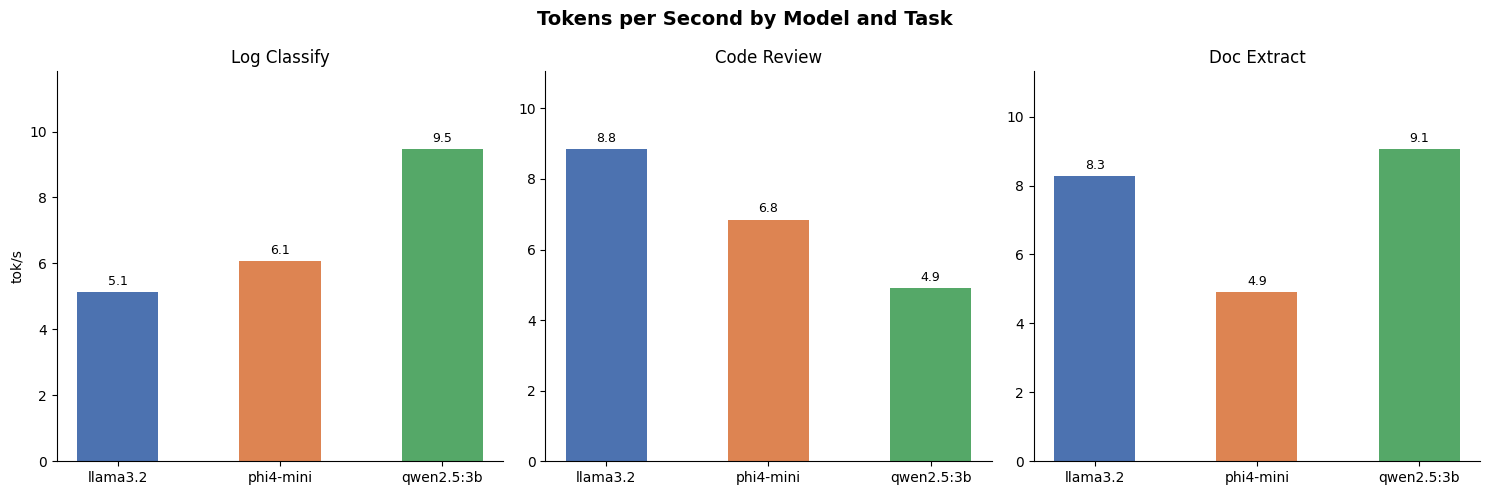

In [4]:
if df is None or "summary" not in dir():
    print("No data loaded. Run cells 1-2 first.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Tokens per Second by Model and Task", fontsize=14, fontweight="bold")

    for ax, task in zip(axes, TASKS):
        task_df = summary[summary.task == task]
        bars = ax.bar(
            task_df.model,
            task_df.avg_toks,
            color=[COLORS.get(m, "#999") for m in task_df.model],
            width=0.5
        )
        ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
        ax.set_title(task.replace("_", " ").title())
        ax.set_ylabel("tok/s" if task == TASKS[0] else "")
        ax.set_ylim(0, task_df.avg_toks.max() * 1.25)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("../benchmark/results/speed_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()


## 4. Schema Validity Rate — by model and task

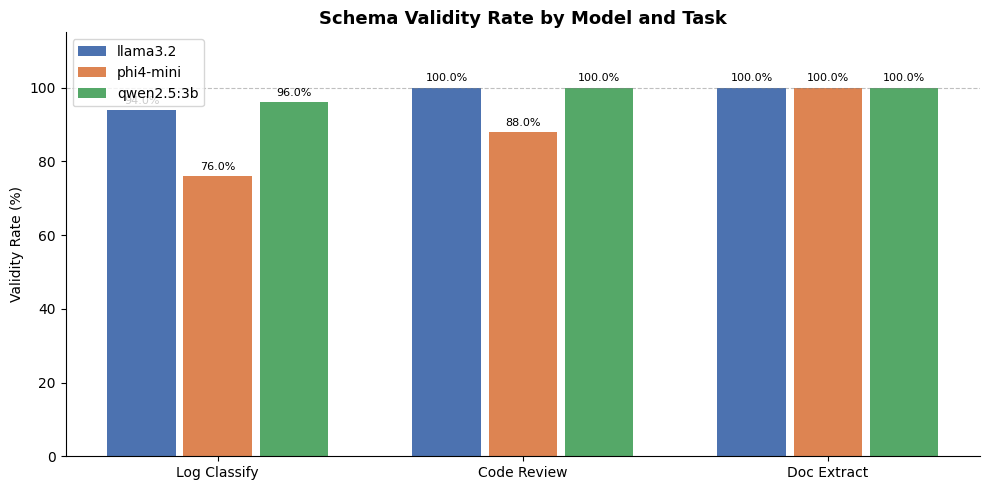

In [5]:
if df is None or "summary" not in dir():
    print("No data loaded. Run cells 1-2 first.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    width = 0.25
    offsets = [-width, 0, width]
    x = range(len(TASKS))

    for offset, model in zip(offsets, MODELS):
        heights = [
            summary[(summary.model == model) & (summary.task == t)]["validity_rate"].values
            for t in TASKS
        ]
        heights = [v[0] if len(v) else 0 for v in heights]
        bars = ax.bar(
            [xi + offset for xi in x],
            heights,
            width=width * 0.9,
            label=model,
            color=COLORS.get(model, "#999")
        )
        ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)

    ax.set_xticks(list(x))
    ax.set_xticklabels([t.replace("_", " ").title() for t in TASKS])
    ax.set_ylabel("Validity Rate (%)")
    ax.set_ylim(0, 115)
    ax.axhline(100, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_title("Schema Validity Rate by Model and Task", fontsize=13, fontweight="bold")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("../benchmark/results/validity_rate.png", dpi=150, bbox_inches="tight")
    plt.show()


## 5. Cold Start vs Warm TTFT

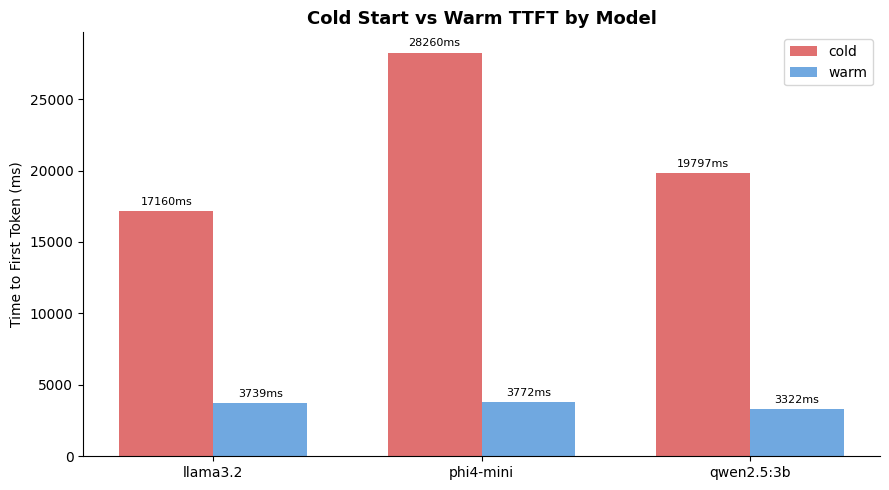

In [6]:
if df is None:
    print("No data loaded. Run cell 1 first.")
else:
    ttft = (
        df.groupby(["model", "cold_start"])["ttft_ms"]
        .mean()
        .round(1)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    width = 0.35

    for i, model in enumerate(MODELS):
        cold_val = ttft[(ttft.model == model) & (ttft.cold_start == True)]["ttft_ms"].values
        warm_val = ttft[(ttft.model == model) & (ttft.cold_start == False)]["ttft_ms"].values
        cold_val = cold_val[0] if len(cold_val) else 0
        warm_val = warm_val[0] if len(warm_val) else 0

        b1 = ax.bar(i - width/2, cold_val, width, label="cold" if i == 0 else "", color="#E07070")
        b2 = ax.bar(i + width/2, warm_val, width, label="warm" if i == 0 else "", color="#70A8E0")
        ax.bar_label(b1, fmt="%.0fms", padding=3, fontsize=8)
        ax.bar_label(b2, fmt="%.0fms", padding=3, fontsize=8)

    ax.set_xticks(range(len(MODELS)))
    ax.set_xticklabels(MODELS)
    ax.set_ylabel("Time to First Token (ms)")
    ax.set_title("Cold Start vs Warm TTFT by Model", fontsize=13, fontweight="bold")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("../benchmark/results/ttft_cold_warm.png", dpi=150, bbox_inches="tight")
    plt.show()


## 6. Validity Rate by Category

Where each model breaks down: clear, ambiguous, edge, negative.

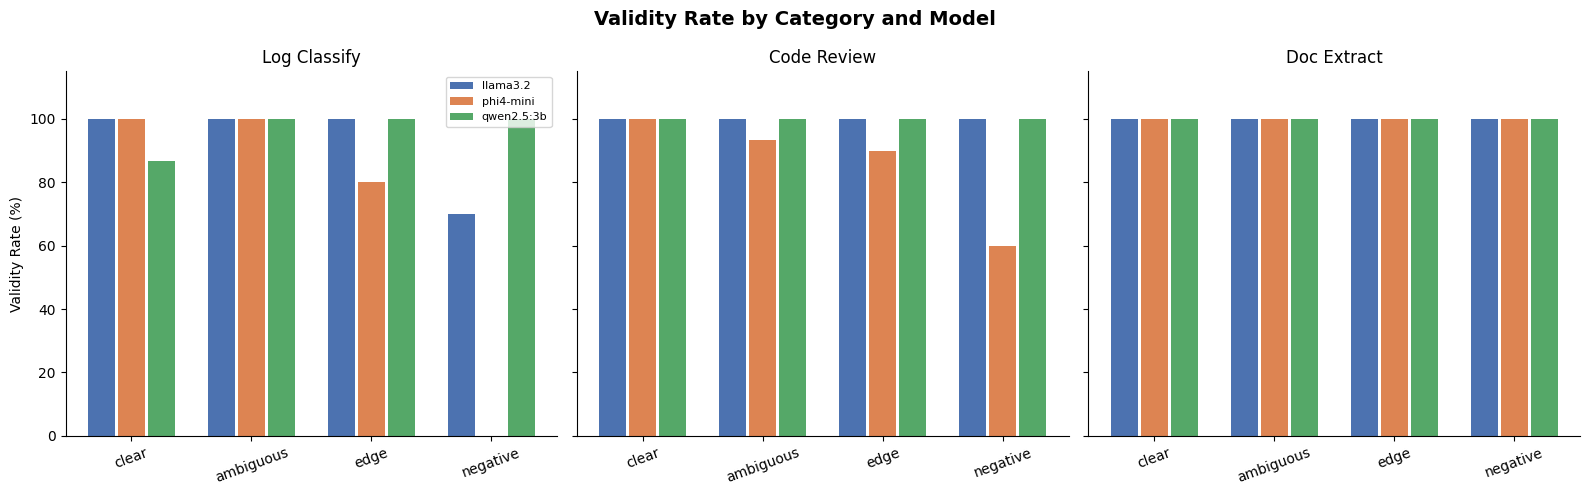

In [7]:
if df is None:
    print("No data loaded. Run cell 1 first.")
else:
    width = 0.25  # defined here so cell is self-contained
    offsets = [-width, 0, width]

    cat_summary = (
        df.groupby(["model", "task", "category"])
        .agg(validity_rate=("success", lambda x: round(x.mean() * 100, 1)))
        .reset_index()
    )

    categories = ["clear", "ambiguous", "edge", "negative"]
    fig, axes = plt.subplots(1, len(TASKS), figsize=(16, 5), sharey=True)
    fig.suptitle("Validity Rate by Category and Model", fontsize=14, fontweight="bold")

    for ax, task in zip(axes, TASKS):
        task_cat = cat_summary[cat_summary.task == task]
        x = range(len(categories))

        for offset, model in zip(offsets, MODELS):
            heights = [
                task_cat[(task_cat.model == model) & (task_cat.category == cat)]["validity_rate"].values
                for cat in categories
            ]
            heights = [v[0] if len(v) else 0 for v in heights]
            ax.bar(
                [xi + offset for xi in x],
                heights,
                width=width * 0.9,
                label=model,
                color=COLORS.get(model, "#999")
            )

        ax.set_xticks(list(x))
        ax.set_xticklabels(categories, rotation=20)
        ax.set_title(task.replace("_", " ").title())
        ax.set_ylim(0, 115)
        if task == TASKS[0]:
            ax.set_ylabel("Validity Rate (%)")
            ax.legend(fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("../benchmark/results/category_breakdown.png", dpi=150, bbox_inches="tight")
    plt.show()


## 7. Retry Rate Analysis

In [8]:
if df is None:
    print("No data loaded. Run cell 1 first.")
else:
    retry_summary = (
        df.groupby(["model", "task"])
        .agg(
            avg_retries      =("retry_count", "mean"),
            pct_needed_retry =("retry_count", lambda x: round((x > 0).mean() * 100, 1))
        )
        .round(3)
        .reset_index()
    )

    print("=== % of prompts that needed at least one retry ===")
    print(
        retry_summary
        .pivot_table(index="model", columns="task", values="pct_needed_retry")
        .round(1)
        .to_string()
    )

    print()
    print("=== Average retry count per call ===")
    print(
        retry_summary
        .pivot_table(index="model", columns="task", values="avg_retries")
        .round(3)
        .to_string()
    )


=== % of prompts that needed at least one retry ===
task        code_review  doc_extract  log_classify
model                                             
llama3.2           0.00         0.00         10.00
phi4-mini         12.00         0.00         24.00
qwen2.5:3b         2.00         0.00          4.00

=== Average retry count per call ===
task        code_review  doc_extract  log_classify
model                                             
llama3.2           0.00         0.00          0.16
phi4-mini          0.24         0.00          0.48
qwen2.5:3b         0.02         0.00          0.08


## 8. Router Recommendations

Pick the best model per task by validity rate, then tok/s as tiebreaker.
Copy the output block into `config.py` → `ROUTER_MODEL_MAP`.

In [9]:
if df is None or "summary" not in dir():
    print("No data loaded. Run cells 1-2 first.")
else:
    print("=== Best model per task ===\n")

    recommendations = {}
    for task in TASKS:
        task_df = summary[summary.task == task].copy()
        best = task_df.sort_values(
            ["validity_rate", "avg_toks"], ascending=[False, False]
        ).iloc[0]
        recommendations[task] = best.model
        print(
            f"{task:<15} -> {best.model:<12} "
            f"validity: {best.validity_rate}%  tok/s: {best.avg_toks:.1f}"
        )

    print()
    print("# Paste this into config.py:")
    print("ROUTER_MODEL_MAP = {")
    for task, model in recommendations.items():
        print(f'    "{task}": "{model}",')
    print("}")


=== Best model per task ===

log_classify    -> qwen2.5:3b   validity: 96.0%  tok/s: 9.5
code_review     -> llama3.2     validity: 100.0%  tok/s: 8.8
doc_extract     -> qwen2.5:3b   validity: 100.0%  tok/s: 9.1

# Paste this into config.py:
ROUTER_MODEL_MAP = {
    "log_classify": "qwen2.5:3b",
    "code_review": "llama3.2",
    "doc_extract": "qwen2.5:3b",
}
